# 公式テスト t4 — Reversible (Diffusion-limited)

> **出典（E-Cell4 公式）**: Tests / Reversible (Diffusion-limited) — https://ecell4.e-cell.org/tests/Reversible_Diffusion_limited.html
>
> t3 と同じ `A + B ⇌ C` だが、会合を速く（`ka_factor=10`）して**拡散律速**の領域にした場合。
> この領域では **well-mixed(ODE) と 空間単分子(spatiocyte/egfrd) がずれる**——それがこのテストの主眼。
> ここでは巨視的 ODE を実行、単分子空間ソルバは参照掲載（重い）。

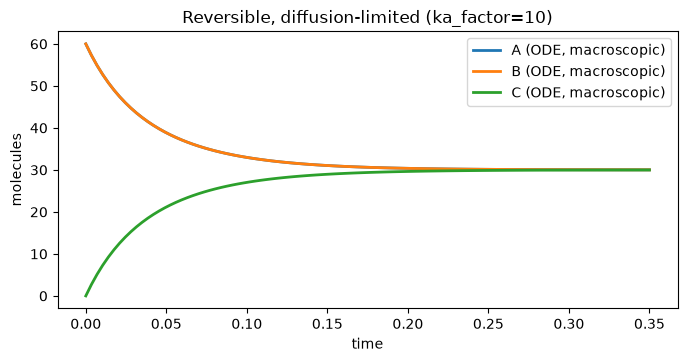

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

D, radius, N_A, U, ka_factor = 1, 0.005, 60, 0.5, 10   # ka_factor=10 -> 拡散律速
kD = 4 * np.pi * (radius * 2) * (D * 2)
ka = kD * ka_factor
kd = ka * N_A * U * U / (1 - U)
kon = ka * kD / (ka + kD)
koff = kd * kon / ka
duration = 0.35
with species_attributes():
    A | B | C | {'radius': radius, 'D': D}
with reaction_rules():
    A + B == C | (kon, koff)
m = get_model()
a = run_simulation(duration, y0={'A': N_A, 'B': N_A}, model=m, species_list=['A','B','C']).as_array()
plt.figure(figsize=(8,3.6))
for i,(lab,c) in enumerate([('A','C0'),('B','C1'),('C','C2')],1):
    plt.plot(a[:,0], a[:,i], color=c, lw=2, label=f'{lab} (ODE, macroscopic)')
plt.xlabel('time'); plt.ylabel('molecules'); plt.legend(); plt.title('Reversible, diffusion-limited (ka_factor=10)'); plt.show()

## 単分子空間ソルバ（公式コード・参照）

```python
# 微視的モデル
with reaction_rules(): A + B == C | (ka, kd)
ret2 = ensemble_simulations(duration, ndiv=20, y0=y0, model=m, solver=('spatiocyte', radius), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0=y0, model=m, solver=('egfrd', Integer3(4,4,4)), repeat=20)
```

**要点**: 反応が拡散に律速される（速い会合）と、分子が「出会うまでの時間」がボトルネックになり、
**well-mixed の仮定（ODE/Gillespie）が破れて空間単分子シミュレーションと乖離する**。この乖離を正しく捉えられるかが
eGFRD/Spatiocyte の存在意義。t3（非律速）では一致し、t4（律速）ではずれる、という対比がテストの核心。